## Model v2


In [ ]:
from pathlib import Path
from typing import Optional
import csv

import numpy as np
from PIL import Image


def analyze_masks(dir_path: str, out_csv: Optional[str] = None) -> None:
    """
    Scan `dir_path` for images, treat non-zero pixels as positive,
    and print + optionally save per-file counts and proportions.

    Args:
        dir_path: Directory containing binary masks (zeros and ones).
        out_csv: Optional path to write CSV with columns:
                 filename,positive_count,negative_count,positive_fraction
    """
    p = Path(dir_path)
    files = sorted([f for f in p.iterdir() if f.is_file()])
    rows = []
    total_pos = 0
    total_pixels = 0

    for f in files:
        im = Image.open(f).convert("L")
        arr = np.asarray(im)
        pos = int((arr > 0).sum())
        tot = int(arr.size)
        neg = tot - pos
        frac = pos / tot if tot > 0 else 0.0
        rows.append((str(f.name), pos, neg, frac))
        total_pos += pos
        total_pixels += tot
        print(f"{f.name}: pos={pos}, neg={neg}, pos_frac={frac:.6f}")

    print(
        f"Summary: files={len(rows)}, total_pos={total_pos}, total_pixels={total_pixels}, overall_pos_frac={total_pos / total_pixels:.6f}"
    )

    if out_csv:
        with open(out_csv, "w", newline="") as fh:
            writer = csv.writer(fh)
            writer.writerow(
                ["filename", "positive_count", "negative_count", "positive_fraction"]
            )
            for r in rows:
                writer.writerow(r)
        print(f"Wrote CSV: {out_csv}")


binary_mask_dir = "../runs/modelv2_results/eval/"
output_dir = "../runs/modelv2_results/stats.csv"
analyze_masks(binary_mask_dir, output_dir)

44984.png: pos=7637, neg=24992363, pos_frac=0.000305
51782.png: pos=14821, neg=24985179, pos_frac=0.000593
51792.png: pos=10347, neg=24989653, pos_frac=0.000414
51793.png: pos=3236, neg=24996764, pos_frac=0.000129
52613.png: pos=16720, neg=24983280, pos_frac=0.000669
52721.png: pos=16057, neg=24983943, pos_frac=0.000642
52722.png: pos=12970, neg=24987030, pos_frac=0.000519
52741.png: pos=11007, neg=24988993, pos_frac=0.000440
52743.png: pos=10483, neg=24989517, pos_frac=0.000419
52744.png: pos=423, neg=24999577, pos_frac=0.000017
52803.png: pos=7051, neg=24992949, pos_frac=0.000282
52814.png: pos=1406, neg=24998594, pos_frac=0.000056
52843.png: pos=15836, neg=24984164, pos_frac=0.000633
52883.png: pos=9, neg=24999991, pos_frac=0.000000
52951.png: pos=12742, neg=24987258, pos_frac=0.000510
52953.png: pos=4271, neg=24995729, pos_frac=0.000171
52983.png: pos=7518, neg=24992482, pos_frac=0.000301
53691.png: pos=14088, neg=24985912, pos_frac=0.000564
53693.png: pos=9717, neg=24990283, pos_f

In [ ]:
import pandas as pd

stats_df = pd.read_csv("../runs/modelv2_results/stats.csv")

display(stats_df)

,filename,positive_count,negative_count,positive_fraction
0,44984.png,7637,24992363,0.000305
1,51782.png,14821,24985179,0.000593
2,51792.png,10347,24989653,0.000414
3,51793.png,3236,24996764,0.000129
4,52613.png,16720,24983280,0.000669
...,...,...,...,...
113,64953.png,9495,24990505,0.000380
114,64962.png,10440,24989560,0.000418
115,64981.png,8641,24991359,0.000346
116,65834.png,1734,24998266,0.000069


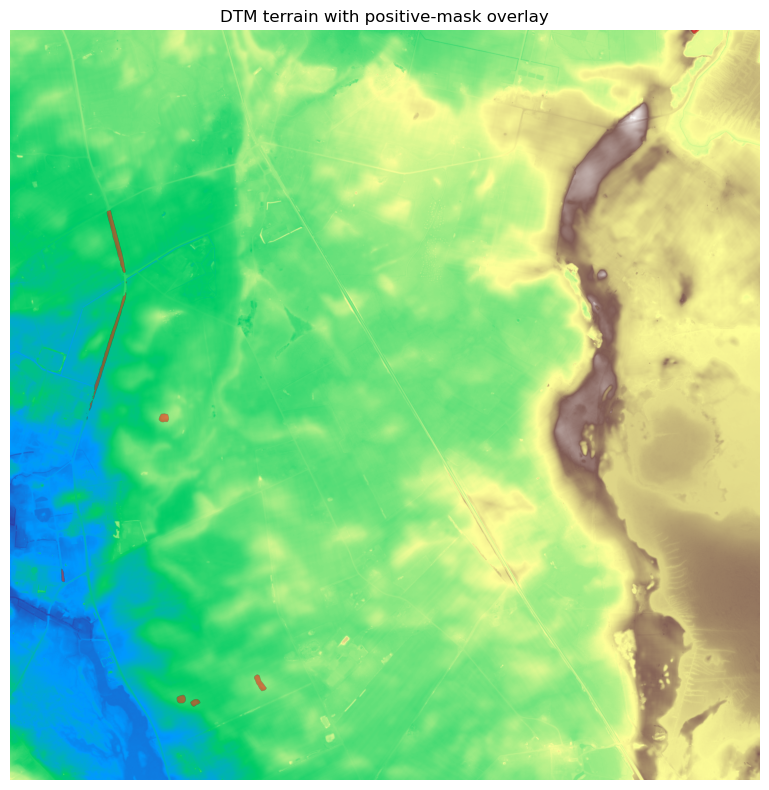

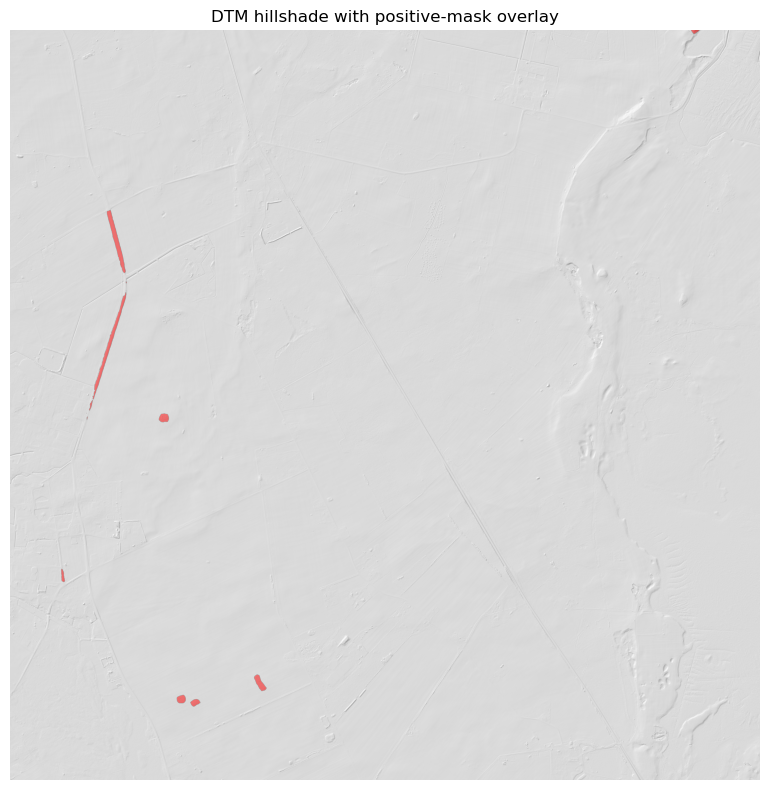

In [6]:
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

try:
    import rasterio
except Exception:
    rasterio = None


def hillshade(
    array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45
) -> np.ndarray:
    """
    Computes hillshade from a 2D array of elevation data.

    Returns a 2D array scaled 0..255 (dtype=float).
    """
    x, y = np.gradient(array.astype(float))
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
    aspect = np.arctan2(-x, y)
    azimuth_rad = azimuth * np.pi / 180.0
    altitude_rad = angle_altitude * np.pi / 180.0
    shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
        slope
    ) * np.cos(azimuth_rad - aspect)
    return 255.0 * (shaded + 1.0) / 2.0


def find_matching_dtm(mask_path: Path, dtm_dir: Path) -> Optional[Path]:
    stem = mask_path.stem
    for ext in (".tif", ".tiff", ".png", ".npy"):
        cand = dtm_dir / (stem + ext)
        if cand.exists():
            return cand
    for f in dtm_dir.rglob("*"):
        if f.is_file() and stem in f.name:
            return f
    return None


def load_mask(mask_path: Path) -> np.ndarray:
    im = Image.open(mask_path).convert("L")
    arr = np.asarray(im)
    return arr > 0


def load_dtm(dtm_path: Path) -> np.ndarray:
    if rasterio and dtm_path.suffix.lower() in (".tif", ".tiff"):
        with rasterio.open(dtm_path) as src:
            dtm = src.read(1).astype(float)
    else:
        dtm = np.asarray(Image.open(dtm_path).convert("F"))
    return dtm


def plot_terrain_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
):
    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(dtm, cmap="terrain")
    ax.set_title("DTM terrain with positive-mask overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


def plot_hillshade_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
    azimuth: int = 315,
    altitude: int = 45,
) -> None:
    # compute hillshade
    hs = hillshade(dtm, azimuth=azimuth, angle_altitude=altitude)

    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(hs, cmap="gray", vmin=0, vmax=255)
    ax.set_title("DTM hillshade with positive-mask overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


binary_mask_image_path = Path("../runs/modelv2_results/eval/63351.png")
dtm_dir = Path("../data/dtm/")
overlay_alpha = 0.5
azimuth = 315
altitude = 45

dtm_p = find_matching_dtm(binary_mask_image_path, dtm_dir)
if dtm_p is None:
    raise SystemExit(
        f"No matching DTM found in {dtm_dir} for mask {binary_mask_image_path}"
    )

mask = load_mask(binary_mask_image_path)
dtm = load_dtm(dtm_p)
plot_terrain_overlay(dtm, mask, overlay_alpha)
plot_hillshade_overlay(dtm, mask, overlay_alpha, azimuth, altitude)

## Model v3


### Statistics


In [68]:
from pathlib import Path
import argparse
import csv
import geopandas as gpd

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import rasterio
except Exception:
    rasterio = None

In [69]:
def load_mask(mask_path: Path) -> np.ndarray:
    im = Image.open(mask_path).convert("L")
    arr = np.asarray(im)
    return arr > 0


def load_dtm(dtm_path: Path) -> np.ndarray:
    if rasterio and dtm_path.suffix.lower() in (".tif", ".tiff"):
        with rasterio.open(dtm_path) as src:
            dtm = src.read(1).astype(float)
    else:
        dtm = np.asarray(Image.open(dtm_path).convert("F"))
    return dtm


def hillshade(
    array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45
) -> np.ndarray:
    """
    Computes hillshade from a 2D array of elevation data.

    Returns a 2D array scaled 0..255 (dtype=float).
    """
    x, y = np.gradient(array.astype(float))
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
    aspect = np.arctan2(-x, y)
    azimuth_rad = azimuth * np.pi / 180.0
    altitude_rad = angle_altitude * np.pi / 180.0
    shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
        slope
    ) * np.cos(azimuth_rad - aspect)
    return 255.0 * (shaded + 1.0) / 2.0


def resize_to(arr: np.ndarray, target_shape):
    img = Image.fromarray((arr * 255).astype(np.uint8))
    img = img.resize((target_shape[1], target_shape[0]), resample=Image.NEAREST)
    return (np.array(img) > 0).astype(np.uint8)


def safe_div(a, b):
    return float(a) / float(b) if b else 0.0


def compute_metrics(gt, pred):
    tp = int(((gt == 1) & (pred == 1)).sum())
    fp = int(((gt == 0) & (pred == 1)).sum())
    fn = int(((gt == 1) & (pred == 0)).sum())
    total = gt.size
    tn = int(total - tp - fp - fn)

    iou = safe_div(tp, tp + fp + fn)
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = (
        safe_div(2 * precision * recall, precision + recall)
        if (precision + recall)
        else 0.0
    )

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "total": total,
        "pos_gt": int(gt.sum()),
        "pos_pred": int(pred.sum()),
        "pos_fraction": float(gt.sum()) / float(total) if total else 0.0,
        "IoU": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_terrain_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
):
    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(dtm, cmap="terrain")
    ax.set_title("DTM terrain with positive-mask (red) overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


def plot_hillshade_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
    azimuth: int = 315,
    altitude: int = 45,
) -> None:
    # compute hillshade
    hs = hillshade(dtm, azimuth=azimuth, angle_altitude=altitude)

    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(hs, cmap="gray", vmin=0, vmax=255)
    ax.set_title("DTM hillshade with positive-mask (red) overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


def plot_dtm_with_two_mask_overlays(
    dtm: np.ndarray,
    gt_mask: np.ndarray,
    pred_mask: np.ndarray,
    gt_color: tuple[float, float, float] = (0.0, 0.0, 1.0),
    pred_color: tuple[float, float, float] = (1.0, 0.0, 0.0),
    alpha: float = 0.6,
    use_hillshade: bool = True,
    azimuth: int = 315,
    altitude: int = 45,
    figsize: tuple[int, int] = (8, 8),
    show: bool = True,
):
    """
    Plot a DTM tile with two mask overlays (ground-truth and prediction) coloured separately.
    - GT is shown using `gt_color`, prediction using `pred_color`.
    - Overlapping pixels are a colour mixture (e.g. red + green -> yellow).
    - Masks may be boolean or integer (0/1 or 0/255) and different shape than `dtm`; function will
      nearest-resize masks to `dtm.shape` if needed (uses `skimage.transform.resize` when available,
      otherwise a simple nearest-neighbour sampling fallback).

    Parameters
    - dtm: 2D array of elevation values.
    - gt_mask: 2D mask array (truth). Any non-zero value is treated as positive.
    - pred_mask: 2D mask array (prediction). Any non-zero value is treated as positive.
    - gt_color: RGB triple for GT overlay (0..1 floats).
    - pred_color: RGB triple for prediction overlay (0..1 floats).
    - alpha: overlay alpha for pixels covered by either mask (0..1).
    - use_hillshade: if True, renders `dtm` as a hillshade background; otherwise uses `dtm` colormap.
    - azimuth, altitude: hillshade parameters.
    - figsize: matplotlib figure size.
    - show: whether to call `plt.show()` before returning.

    Returns
    - (fig, ax): the matplotlib figure and axis objects.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Helpers copied/compatible with your code - ensure boolean masks
    gt = (gt_mask > 0).astype(bool)
    pr = (pred_mask > 0).astype(bool)

    # Resize masks to dtm.shape if needed (prefer skimage, otherwise nearest sampling)
    target_shape = dtm.shape
    if gt.shape != target_shape or pr.shape != target_shape:
        try:
            from skimage.transform import resize

            gt_res = (
                resize(gt.astype(float), target_shape, order=0, preserve_range=True)
                >= 0.5
            )
            pr_res = (
                resize(pr.astype(float), target_shape, order=0, preserve_range=True)
                >= 0.5
            )
            gt, pr = gt_res, pr_res
        except Exception:
            # nearest-neighbour sampling fallback
            yy = np.linspace(0, gt.shape[0] - 1, target_shape[0]).round().astype(int)
            xx = np.linspace(0, gt.shape[1] - 1, target_shape[1]).round().astype(int)
            gt = gt[np.ix_(yy, xx)]
            yy2 = (
                np.linspace(0, pred_mask.shape[0] - 1, target_shape[0])
                .round()
                .astype(int)
            )
            xx2 = (
                np.linspace(0, pred_mask.shape[1] - 1, target_shape[1])
                .round()
                .astype(int)
            )
            pr = pred_mask[np.ix_(yy2, xx2)] > 0

    # Prepare background (hillshade or raw dtm)
    def hillshade(
        array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45
    ) -> np.ndarray:
        x, y = np.gradient(array.astype(float))
        slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
        aspect = np.arctan2(-x, y)
        azimuth_rad = azimuth * np.pi / 180.0
        altitude_rad = angle_altitude * np.pi / 180.0
        shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
            slope
        ) * np.cos(azimuth_rad - aspect)
        return 255.0 * (shaded + 1.0) / 2.0

    if use_hillshade:
        bg = hillshade(dtm, azimuth=azimuth, angle_altitude=altitude)
        cmap = "gray"
        vmin, vmax = 0, 255
    else:
        bg = dtm
        cmap = "terrain"
        vmin, vmax = None, None

    # Build RGBA overlay: mix colours where both masks are present
    overlay = np.zeros((target_shape[0], target_shape[1], 4), dtype=float)

    # Add GT contribution
    if np.any(gt):
        for c in range(3):
            overlay[..., c] += gt.astype(float) * float(gt_color[c])
    # Add prediction contribution
    if np.any(pr):
        for c in range(3):
            overlay[..., c] += pr.astype(float) * float(pred_color[c])

    # Ensure colour values are clamped to [0,1]
    overlay[..., :3] = np.clip(overlay[..., :3], 0.0, 1.0)

    # Alpha channel: set to alpha where either mask present
    overlay[..., 3] = alpha * ((gt | pr).astype(float))

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(bg, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title("DTM with GT (blue) and Pred (red) overlays")
    ax.axis("off")
    ax.imshow(overlay, interpolation="nearest")
    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

In [70]:
gt_dir = "../data/gt_masks/"
pred_dir = "../runs/modelv3_results/eval/"
out_csv = "../runs/modelv3_results/eval_metrics.csv"

gt_dir = Path(gt_dir)
pred_dir = Path(pred_dir)
out_csv = Path(out_csv)

gt_files = {p.stem: p for p in gt_dir.glob("*.png")}
pred_files = {p.stem: p for p in pred_dir.glob("*.png")}

keys = sorted(set(gt_files.keys()) | set(pred_files.keys()))
if not keys:
    print("No PNG masks found in the provided directories.")

rows = []
sums = {"TP": 0, "FP": 0, "FN": 0, "TN": 0, "total": 0}

for k in keys:
    gt_path = gt_files.get(k)
    pred_path = pred_files.get(k)

    if gt_path is None:
        # treat missing GT as empty mask
        gt = np.zeros((5000, 5000), dtype=np.uint8)
    else:
        gt = load_mask(gt_path)

    if pred_path is None:
        pred = np.zeros_like(gt)
    else:
        pred = load_mask(pred_path)

    # resize pred to gt if shapes mismatch
    if pred.shape != gt.shape:
        pred = resize_to(pred, gt.shape)

    m = compute_metrics(gt, pred)
    sums["TP"] += m["TP"]
    sums["FP"] += m["FP"]
    sums["FN"] += m["FN"]
    sums["TN"] += m["TN"]
    sums["total"] += m["total"]

    rows.append(
        {
            "tile": k,
            "gt_path": str(gt_path) if gt_path else "",
            "pred_path": str(pred_path) if pred_path else "",
            "TP": m["TP"],
            "FP": m["FP"],
            "FN": m["FN"],
            "TN": m["TN"],
            "total_pixels": m["total"],
            "pos_gt": m["pos_gt"],
            "pos_pred": m["pos_pred"],
            "pos_fraction": m["pos_fraction"],
            "IoU": m["IoU"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
        }
    )

# build DataFrame from collected rows
df = pd.DataFrame(rows)

# compute global aggregates (same as before)
global_iou = safe_div(sums["TP"], sums["TP"] + sums["FP"] + sums["FN"])
global_precision = safe_div(sums["TP"], sums["TP"] + sums["FP"])
global_recall = safe_div(sums["TP"], sums["TP"] + sums["FN"])
global_f1 = (
    safe_div(2 * global_precision * global_recall, global_precision + global_recall)
    if (global_precision + global_recall)
    else 0.0
)

# aggregate row
agg = {
    "tile": "AGGREGATE",
    "gt_path": "",
    "pred_path": "",
    "TP": sums["TP"],
    "FP": sums["FP"],
    "FN": sums["FN"],
    "TN": sums["TN"],
    "total_pixels": sums["total"],
    "pos_gt": "",
    "pos_pred": "",
    "pos_fraction": "",
    "IoU": global_iou,
    "precision": global_precision,
    "recall": global_recall,
    "f1": global_f1,
}

In [71]:
# append aggregate and write CSV
df_out = pd.concat([df, pd.DataFrame([agg])], ignore_index=True)
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(out_csv, index=False)

print(f"Wrote metrics for {len(rows)} tiles to {out_csv}")
print("Global metrics:")
print(
    f"  IoU={global_iou:.6f}  precision={global_precision:.6f}  recall={global_recall:.6f}  f1={global_f1:.6f}"
)

Wrote metrics for 118 tiles to ..\runs\modelv3_results\eval_metrics.csv
Global metrics:
  IoU=0.331862  precision=0.649284  recall=0.404344  f1=0.498343


In [72]:
df_eval_results = pd.read_csv("../runs/modelv3_results/eval_metrics.csv")
display(df_eval_results)

,tile,gt_path,pred_path,TP,FP,FN,TN,total_pixels,pos_gt,pos_pred,pos_fraction,IoU,precision,recall,f1
0,44984,..\data\gt_masks\44984.png,..\runs\modelv3_results\eval\44984.png,10021,705,35281,24953993,25000000,45302.0,10726.0,0.001812,0.217815,0.934272,0.221204,0.357714
1,51782,..\data\gt_masks\51782.png,..\runs\modelv3_results\eval\51782.png,13831,1097,2889,24982183,25000000,16720.0,14928.0,0.000669,0.776281,0.926514,0.827213,0.874052
2,51792,..\data\gt_masks\51792.png,..\runs\modelv3_results\eval\51792.png,24653,2180,11744,24961423,25000000,36397.0,26833.0,0.001456,0.639060,0.918757,0.677336,0.779788
3,51793,..\data\gt_masks\51793.png,..\runs\modelv3_results\eval\51793.png,3030,844,155,24995971,25000000,3185.0,3874.0,0.000127,0.752048,0.782137,0.951334,0.858479
4,52613,..\data\gt_masks\52613.png,..\runs\modelv3_results\eval\52613.png,16652,1713,29,24981606,25000000,16681.0,18365.0,0.000667,0.905295,0.906725,0.998261,0.950294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,64962,..\data\gt_masks\64962.png,..\runs\modelv3_results\eval\64962.png,10970,3292,12871,24972867,25000000,23841.0,14262.0,0.000954,0.404305,0.769177,0.460132,0.575808
115,64981,..\data\gt_masks\64981.png,..\runs\modelv3_results\eval\64981.png,8708,1220,207,24989865,25000000,8915.0,9928.0,0.000357,0.859201,0.877115,0.976781,0.924269
116,65834,..\data\gt_masks\65834.png,..\runs\modelv3_results\eval\65834.png,1596,2013,632,24995759,25000000,2228.0,3609.0,0.000089,0.376326,0.442228,0.716338,0.546856
117,74032,..\data\gt_masks\74032.png,..\runs\modelv3_results\eval\74032.png,6811,1403,11887,24979899,25000000,18698.0,8214.0,0.000748,0.338839,0.829194,0.364264,0.506168


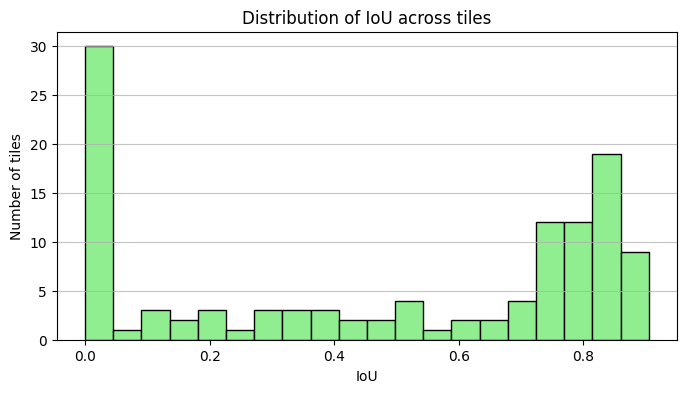

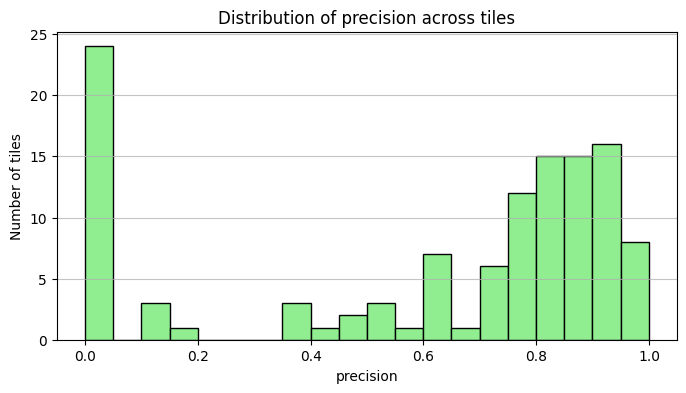

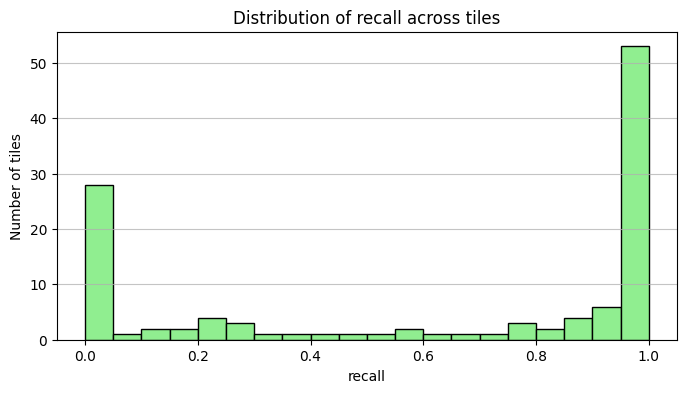

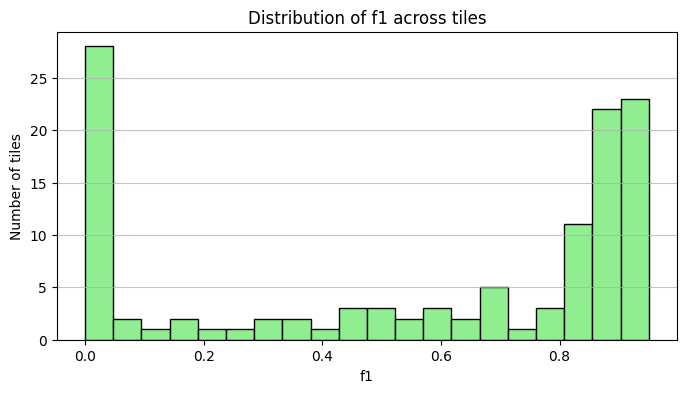

In [73]:
# Plot evaluation metrics distribution
metrics = ["IoU", "precision", "recall", "f1"]
for metric in metrics:
    plt.figure(figsize=(8, 4))
    plt.hist(
        df_eval_results[metric][:-1], bins=20, color="lightgreen", edgecolor="black"
    )
    plt.title(f"Distribution of {metric} across tiles")
    plt.xlabel(metric)
    plt.ylabel("Number of tiles")
    plt.grid(axis="y", alpha=0.75)
    # Save plot
    plt.savefig(f"../runs/modelv3_results/{metric}_distribution.png", dpi=300)
    plt.show()

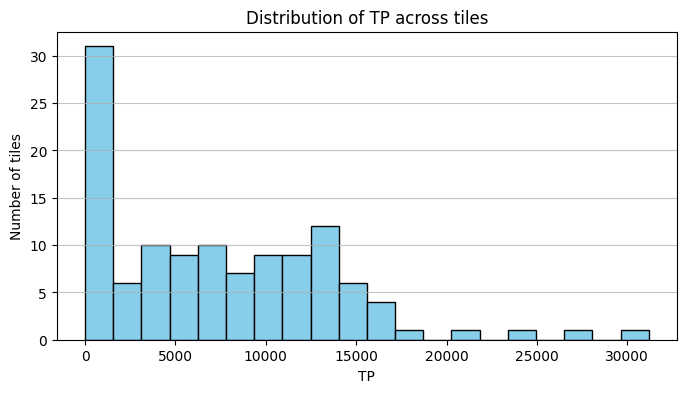

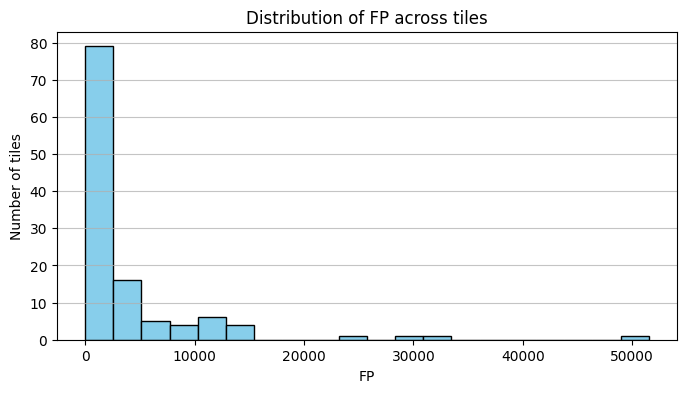

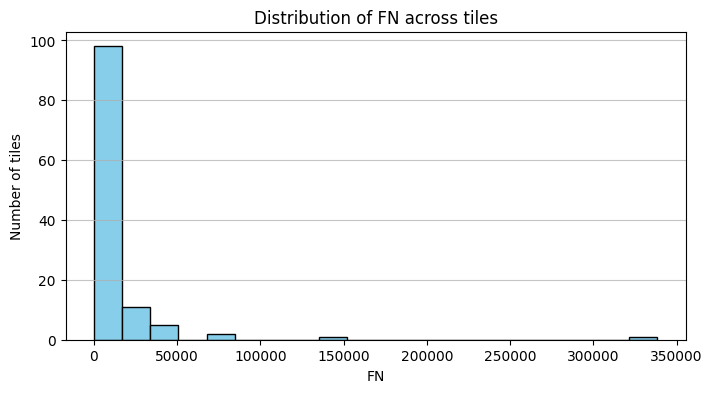

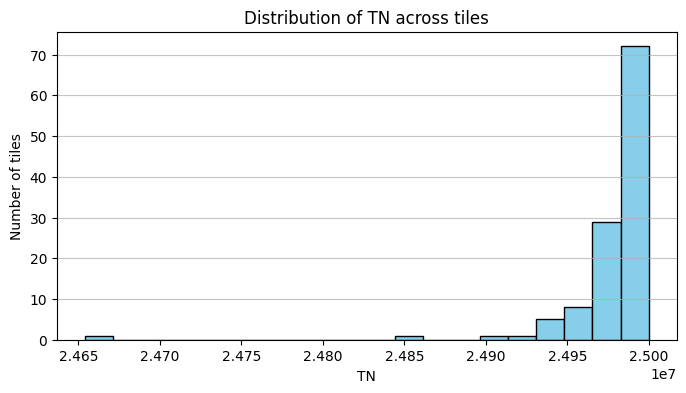

In [74]:
# Plot confusion matrix components distribution
confusion_components = ["TP", "FP", "FN", "TN"]
for component in confusion_components:
    plt.figure(figsize=(8, 4))
    plt.hist(
        df_eval_results[component][:-1], bins=20, color="skyblue", edgecolor="black"
    )
    plt.title(f"Distribution of {component} across tiles")
    plt.xlabel(component)
    plt.ylabel("Number of tiles")
    plt.grid(axis="y", alpha=0.75)
    # Save plot
    plt.savefig(f"../runs/modelv3_results/{component}_distribution.png", dpi=300)
    plt.show()

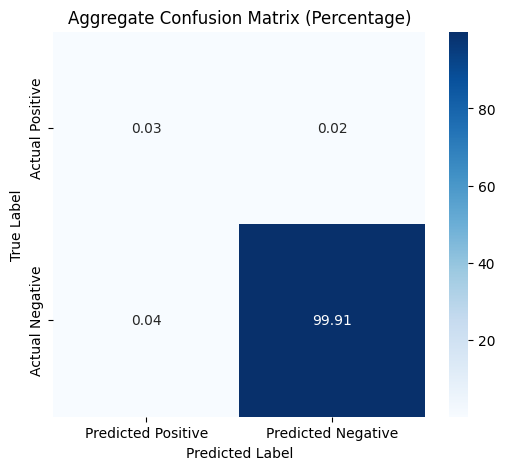

In [75]:
# Plot aggregate confusion matrix
confusion_matrix = np.array(
    [
        [df_eval_results["TP"].iloc[-1], df_eval_results["FP"].iloc[-1]],
        [df_eval_results["FN"].iloc[-1], df_eval_results["TN"].iloc[-1]],
    ]
)
# Convert to percentages
confusion_matrix_percent = confusion_matrix / confusion_matrix.sum() * 100.0

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Predicted Positive", "Predicted Negative"],
    yticklabels=["Actual Positive", "Actual Negative"],
)
plt.title("Aggregate Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# Save plot
plt.savefig("../runs/modelv3_results/aggregate_confusion_matrix.png")
plt.show()

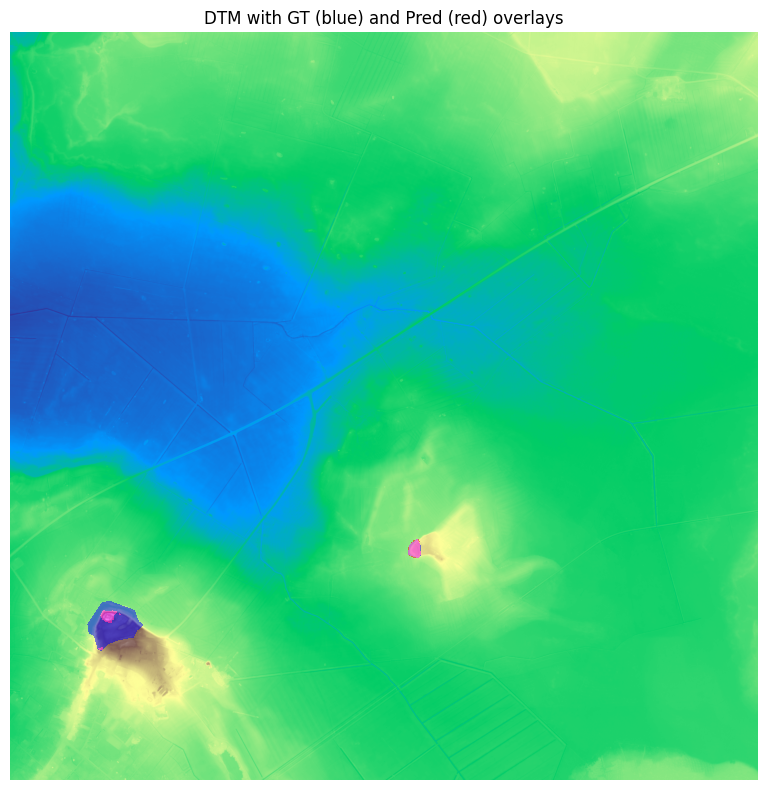

In [76]:
# Choose a single DTM tile to visualize predictions vs ground truth
tile_id = "62093"  # replace with desired tile ID

dtm_path = Path(f"../data/dtm/{tile_id}.tif")
gt_mask_path = Path(f"../data/gt_masks/{tile_id}.png")
pred_mask_path = Path(f"../runs/modelv3_results/eval/{tile_id}.png")
gt_mask = load_mask(gt_mask_path)
pred_mask = load_mask(pred_mask_path)

# print("paths exist:", dtm_path.exists(), gt_mask_path.exists(), pred_mask_path.exists())

# print("shapes:", "dtm unknown here", "gt", gt_mask.shape, "pred", pred_mask.shape)
# print("sums:", "gt_sum", int(gt_mask.sum()), "pred_sum", int(pred_mask.sum()))
# print("gt unique:", np.unique(gt_mask), "pred unique:", np.unique(pred_mask))

# Visualise ground truth mask and predicted mask overlays on DTM
dtm = load_dtm(dtm_path)
fig, ax = plot_dtm_with_two_mask_overlays(
    dtm,
    gt_mask,
    pred_mask,
    alpha=0.5,
    use_hillshade=False,
    # azimuth=315,
    # altitude=45,
    # figsize=(8, 8),
)
# Save plot
fig.savefig(
    f"../runs/modelv3_results/dtm_{tile_id}_gt_pred_overlay_terrain.png", dpi=300
)
plt.show()

### Example of the most positive predicted map tile


In [77]:
from pathlib import Path
from typing import Optional
import csv

import numpy as np
from PIL import Image


def analyze_masks(dir_path: str, out_csv: Optional[str] = None) -> None:
    """
    Scan `dir_path` for images, treat non-zero pixels as positive,
    and print + optionally save per-file counts and proportions.

    Args:
        dir_path: Directory containing binary masks (zeros and ones).
        out_csv: Optional path to write CSV with columns:
                 filename,positive_count,negative_count,positive_fraction
    """
    p = Path(dir_path)
    files = sorted([f for f in p.iterdir() if f.is_file()])
    rows = []
    total_pos = 0
    total_pixels = 0

    for f in files:
        im = Image.open(f).convert("L")
        arr = np.asarray(im)
        pos = int((arr > 0).sum())
        tot = int(arr.size)
        neg = tot - pos
        frac = pos / tot if tot > 0 else 0.0
        rows.append((str(f.name), pos, neg, frac))
        total_pos += pos
        total_pixels += tot
        print(f"{f.name}: pos={pos}, neg={neg}, pos_frac={frac:.6f}")

    print(
        f"Summary: files={len(rows)}, total_pos={total_pos}, total_pixels={total_pixels}, overall_pos_frac={total_pos / total_pixels:.6f}"
    )

    if out_csv:
        with open(out_csv, "w", newline="") as fh:
            writer = csv.writer(fh)
            writer.writerow(
                ["filename", "positive_count", "negative_count", "positive_fraction"]
            )
            for r in rows:
                writer.writerow(r)
        print(f"Wrote CSV: {out_csv}")


binary_mask_dir = "../runs/modelv3_results/eval/"
output_dir = "../runs/modelv3_results/pred_stats.csv"
analyze_masks(binary_mask_dir, output_dir)

44984.png: pos=10726, neg=24989274, pos_frac=0.000429
51782.png: pos=14928, neg=24985072, pos_frac=0.000597
51792.png: pos=26833, neg=24973167, pos_frac=0.001073
51793.png: pos=3874, neg=24996126, pos_frac=0.000155
52613.png: pos=18365, neg=24981635, pos_frac=0.000735
52721.png: pos=19699, neg=24980301, pos_frac=0.000788
52722.png: pos=14341, neg=24985659, pos_frac=0.000574
52741.png: pos=13458, neg=24986542, pos_frac=0.000538
52743.png: pos=13880, neg=24986120, pos_frac=0.000555
52744.png: pos=1791, neg=24998209, pos_frac=0.000072
52803.png: pos=8866, neg=24991134, pos_frac=0.000355
52814.png: pos=2701, neg=24997299, pos_frac=0.000108
52843.png: pos=19113, neg=24980887, pos_frac=0.000765
52883.png: pos=359, neg=24999641, pos_frac=0.000014
52951.png: pos=14335, neg=24985665, pos_frac=0.000573
52953.png: pos=5811, neg=24994189, pos_frac=0.000232
52983.png: pos=8594, neg=24991406, pos_frac=0.000344
53691.png: pos=16377, neg=24983623, pos_frac=0.000655
53693.png: pos=13039, neg=24986961, 

In [78]:
import pandas as pd

stats_df = pd.read_csv("../runs/modelv3_results/pred_stats.csv")

display(stats_df.sort_values(by="positive_count", ascending=False).head(10))

,filename,positive_count,negative_count,positive_fraction
72,63351.png,52381,24947619,0.002095
112,64951.png,34113,24965887,0.001365
95,64244.png,32304,24967696,0.001292
111,64933.png,30851,24969149,0.001234
106,64744.png,29345,24970655,0.001174
110,64873.png,28529,24971471,0.001141
37,54344.png,27566,24972434,0.001103
79,63694.png,27126,24972874,0.001085
2,51792.png,26833,24973167,0.001073
107,64784.png,25413,24974587,0.001017


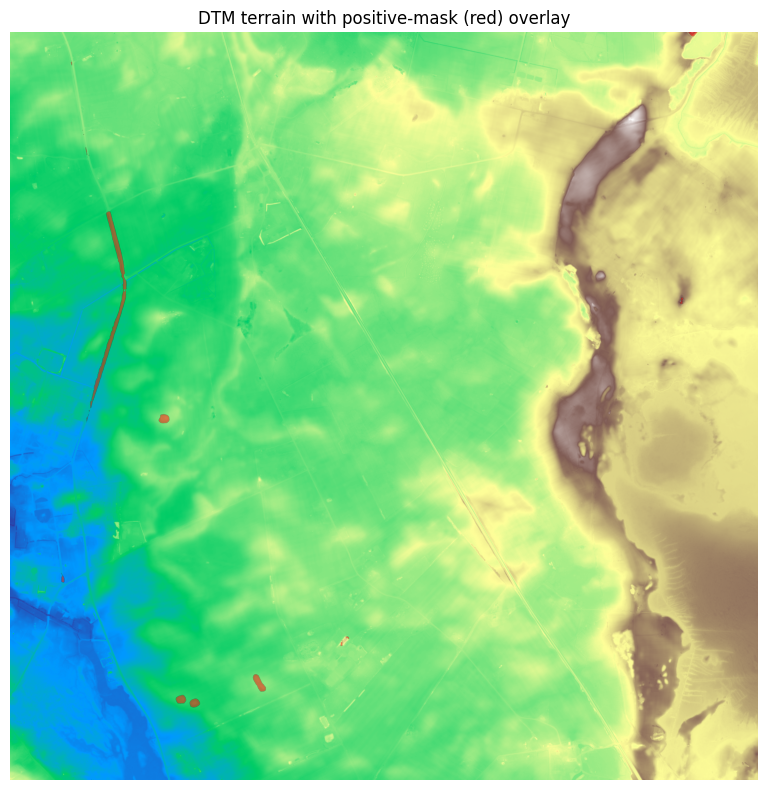

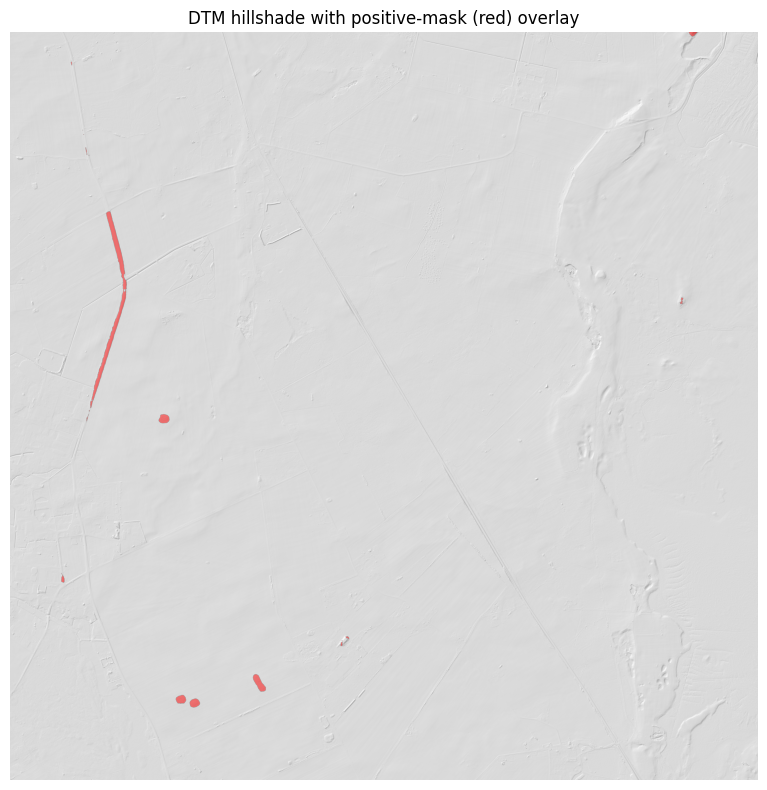

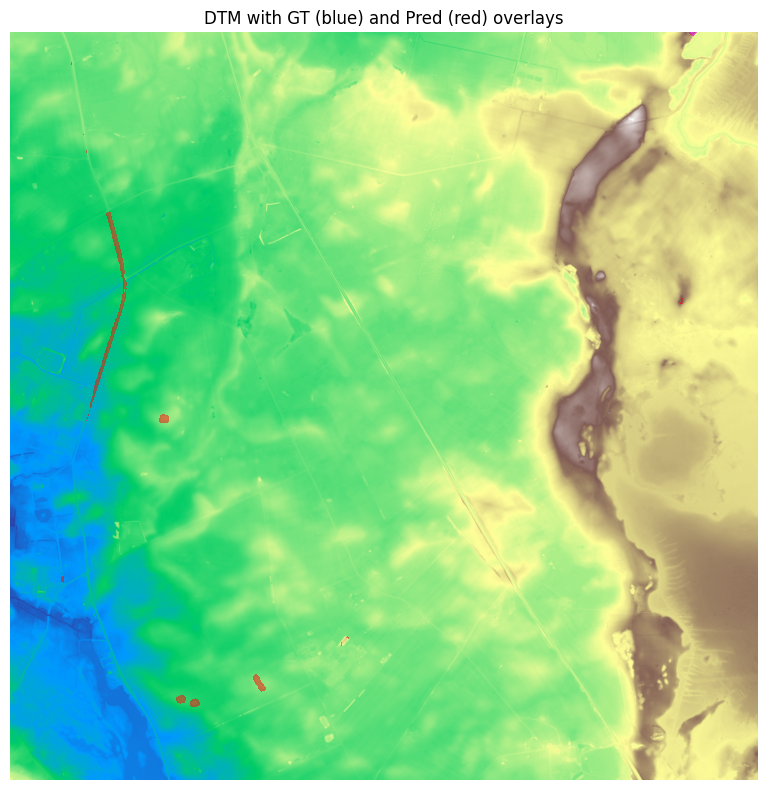

In [79]:
# Choose a single DTM tile to visualize predictions vs ground truth
tile_id = "63351"  # replace with desired tile ID

dtm_path = Path(f"../data/dtm/{tile_id}.tif")
gt_mask_path = Path(f"../data/gt_masks/{tile_id}.png")
pred_mask_path = Path(f"../runs/modelv3_results/eval/{tile_id}.png")
gt_mask = load_mask(gt_mask_path)
pred_mask = load_mask(pred_mask_path)
dtm = load_dtm(dtm_path)

overlay_alpha = 0.5
azimuth = 315
altitude = 45

# print("paths exist:", dtm_path.exists(), gt_mask_path.exists(), pred_mask_path.exists())

# print("shapes:", "dtm unknown here", "gt", gt_mask.shape, "pred", pred_mask.shape)
# print("sums:", "gt_sum", int(gt_mask.sum()), "pred_sum", int(pred_mask.sum()))
# print("gt unique:", np.unique(gt_mask), "pred unique:", np.unique(pred_mask))

# Visualise predicted mask overlay on different terrain backgrounds
plot_terrain_overlay(dtm, pred_mask, overlay_alpha)
plot_hillshade_overlay(dtm, pred_mask, overlay_alpha, azimuth, altitude)

# Visualise ground truth mask and predicted mask overlays on DTM
fig, ax = plot_dtm_with_two_mask_overlays(
    dtm,
    gt_mask,
    pred_mask,
    alpha=0.5,
    use_hillshade=False,
    # azimuth=315,
    # altitude=45,
    # figsize=(8, 8),
)
# Save plot
fig.savefig(
    f"../runs/modelv3_results/dtm_{tile_id}_gt_pred_overlay_terrain.png", dpi=300
)
plt.show()

## Model v4


### Ground truth masks analysis


In [67]:
from pathlib import Path
import numpy as np
import os

# paths
stem = Path("../data/gt_masks/")
mask_ps = os.listdir(stem)

for mask_p in mask_ps:
    mask_p = os.path.join(stem, mask_p)

    # load like your script
    mask = np.asarray(Image.open(mask_p).convert("L")) > 0
    if int(mask.sum()) == 0:
        print("zero mask:", mask_p)
        print("mask.shape, dtype, sum:", mask.shape, mask.dtype, int(mask.sum()))

zero mask: ..\data\gt_masks\52744.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\52883.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\53693.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\53932.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\54342.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\54382.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\55214.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\63843.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\63981.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\64101.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\64354.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\data\gt_masks\64642.png
mask.shape, dtype, sum: (5000, 5000) bool 0
zero mask: ..\da

### Statistics


In [80]:
from pathlib import Path
import argparse
import csv
import geopandas as gpd

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import rasterio
except Exception:
    rasterio = None

In [81]:
def load_mask(mask_path: Path) -> np.ndarray:
    im = Image.open(mask_path).convert("L")
    arr = np.asarray(im)
    return arr > 0


def load_dtm(dtm_path: Path) -> np.ndarray:
    if rasterio and dtm_path.suffix.lower() in (".tif", ".tiff"):
        with rasterio.open(dtm_path) as src:
            dtm = src.read(1).astype(float)
    else:
        dtm = np.asarray(Image.open(dtm_path).convert("F"))
    return dtm


def hillshade(
    array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45
) -> np.ndarray:
    """
    Computes hillshade from a 2D array of elevation data.

    Returns a 2D array scaled 0..255 (dtype=float).
    """
    x, y = np.gradient(array.astype(float))
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
    aspect = np.arctan2(-x, y)
    azimuth_rad = azimuth * np.pi / 180.0
    altitude_rad = angle_altitude * np.pi / 180.0
    shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
        slope
    ) * np.cos(azimuth_rad - aspect)
    return 255.0 * (shaded + 1.0) / 2.0


def resize_to(arr: np.ndarray, target_shape):
    img = Image.fromarray((arr * 255).astype(np.uint8))
    img = img.resize((target_shape[1], target_shape[0]), resample=Image.NEAREST)
    return (np.array(img) > 0).astype(np.uint8)


def safe_div(a, b):
    return float(a) / float(b) if b else 0.0


def compute_metrics(gt, pred):
    tp = int(((gt == 1) & (pred == 1)).sum())
    fp = int(((gt == 0) & (pred == 1)).sum())
    fn = int(((gt == 1) & (pred == 0)).sum())
    total = gt.size
    tn = int(total - tp - fp - fn)

    iou = safe_div(tp, tp + fp + fn)
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = (
        safe_div(2 * precision * recall, precision + recall)
        if (precision + recall)
        else 0.0
    )

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "total": total,
        "pos_gt": int(gt.sum()),
        "pos_pred": int(pred.sum()),
        "pos_fraction": float(gt.sum()) / float(total) if total else 0.0,
        "IoU": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_terrain_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
):
    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(dtm, cmap="terrain")
    ax.set_title("DTM terrain with positive-mask (red) overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


def plot_hillshade_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
    azimuth: int = 315,
    altitude: int = 45,
) -> None:
    # compute hillshade
    hs = hillshade(dtm, azimuth=azimuth, angle_altitude=altitude)

    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(hs, cmap="gray", vmin=0, vmax=255)
    ax.set_title("DTM hillshade with positive-mask (red) overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


def plot_dtm_with_two_mask_overlays(
    dtm: np.ndarray,
    gt_mask: np.ndarray,
    pred_mask: np.ndarray,
    gt_color: tuple[float, float, float] = (0.0, 0.0, 1.0),
    pred_color: tuple[float, float, float] = (1.0, 0.0, 0.0),
    alpha: float = 0.6,
    use_hillshade: bool = True,
    azimuth: int = 315,
    altitude: int = 45,
    figsize: tuple[int, int] = (8, 8),
    show: bool = True,
):
    """
    Plot a DTM tile with two mask overlays (ground-truth and prediction) coloured separately.
    - GT is shown using `gt_color`, prediction using `pred_color`.
    - Overlapping pixels are a colour mixture (e.g. red + green -> yellow).
    - Masks may be boolean or integer (0/1 or 0/255) and different shape than `dtm`; function will
      nearest-resize masks to `dtm.shape` if needed (uses `skimage.transform.resize` when available,
      otherwise a simple nearest-neighbour sampling fallback).

    Parameters
    - dtm: 2D array of elevation values.
    - gt_mask: 2D mask array (truth). Any non-zero value is treated as positive.
    - pred_mask: 2D mask array (prediction). Any non-zero value is treated as positive.
    - gt_color: RGB triple for GT overlay (0..1 floats).
    - pred_color: RGB triple for prediction overlay (0..1 floats).
    - alpha: overlay alpha for pixels covered by either mask (0..1).
    - use_hillshade: if True, renders `dtm` as a hillshade background; otherwise uses `dtm` colormap.
    - azimuth, altitude: hillshade parameters.
    - figsize: matplotlib figure size.
    - show: whether to call `plt.show()` before returning.

    Returns
    - (fig, ax): the matplotlib figure and axis objects.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Helpers copied/compatible with your code - ensure boolean masks
    gt = (gt_mask > 0).astype(bool)
    pr = (pred_mask > 0).astype(bool)

    # Resize masks to dtm.shape if needed (prefer skimage, otherwise nearest sampling)
    target_shape = dtm.shape
    if gt.shape != target_shape or pr.shape != target_shape:
        try:
            from skimage.transform import resize

            gt_res = (
                resize(gt.astype(float), target_shape, order=0, preserve_range=True)
                >= 0.5
            )
            pr_res = (
                resize(pr.astype(float), target_shape, order=0, preserve_range=True)
                >= 0.5
            )
            gt, pr = gt_res, pr_res
        except Exception:
            # nearest-neighbour sampling fallback
            yy = np.linspace(0, gt.shape[0] - 1, target_shape[0]).round().astype(int)
            xx = np.linspace(0, gt.shape[1] - 1, target_shape[1]).round().astype(int)
            gt = gt[np.ix_(yy, xx)]
            yy2 = (
                np.linspace(0, pred_mask.shape[0] - 1, target_shape[0])
                .round()
                .astype(int)
            )
            xx2 = (
                np.linspace(0, pred_mask.shape[1] - 1, target_shape[1])
                .round()
                .astype(int)
            )
            pr = pred_mask[np.ix_(yy2, xx2)] > 0

    # Prepare background (hillshade or raw dtm)
    def hillshade(
        array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45
    ) -> np.ndarray:
        x, y = np.gradient(array.astype(float))
        slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
        aspect = np.arctan2(-x, y)
        azimuth_rad = azimuth * np.pi / 180.0
        altitude_rad = angle_altitude * np.pi / 180.0
        shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
            slope
        ) * np.cos(azimuth_rad - aspect)
        return 255.0 * (shaded + 1.0) / 2.0

    if use_hillshade:
        bg = hillshade(dtm, azimuth=azimuth, angle_altitude=altitude)
        cmap = "gray"
        vmin, vmax = 0, 255
    else:
        bg = dtm
        cmap = "terrain"
        vmin, vmax = None, None

    # Build RGBA overlay: mix colours where both masks are present
    overlay = np.zeros((target_shape[0], target_shape[1], 4), dtype=float)

    # Add GT contribution
    if np.any(gt):
        for c in range(3):
            overlay[..., c] += gt.astype(float) * float(gt_color[c])
    # Add prediction contribution
    if np.any(pr):
        for c in range(3):
            overlay[..., c] += pr.astype(float) * float(pred_color[c])

    # Ensure colour values are clamped to [0,1]
    overlay[..., :3] = np.clip(overlay[..., :3], 0.0, 1.0)

    # Alpha channel: set to alpha where either mask present
    overlay[..., 3] = alpha * ((gt | pr).astype(float))

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(bg, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title("DTM with GT (blue) and Pred (red) overlays")
    ax.axis("off")
    ax.imshow(overlay, interpolation="nearest")
    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

In [82]:
gt_dir = "../data/gt_masks/"
pred_dir = "../runs/modelv4_results/eval/"
out_csv = "../runs/modelv4_results/eval_metrics.csv"

gt_dir = Path(gt_dir)
pred_dir = Path(pred_dir)
out_csv = Path(out_csv)

gt_files = {p.stem: p for p in gt_dir.glob("*.png")}
pred_files = {p.stem: p for p in pred_dir.glob("*.png")}

keys = sorted(set(gt_files.keys()) | set(pred_files.keys()))
if not keys:
    print("No PNG masks found in the provided directories.")

rows = []
sums = {"TP": 0, "FP": 0, "FN": 0, "TN": 0, "total": 0}

for k in keys:
    gt_path = gt_files.get(k)
    pred_path = pred_files.get(k)

    if gt_path is None:
        # treat missing GT as empty mask
        gt = np.zeros((5000, 5000), dtype=np.uint8)
    else:
        gt = load_mask(gt_path)

    if pred_path is None:
        pred = np.zeros_like(gt)
    else:
        pred = load_mask(pred_path)

    # resize pred to gt if shapes mismatch
    if pred.shape != gt.shape:
        pred = resize_to(pred, gt.shape)

    m = compute_metrics(gt, pred)
    sums["TP"] += m["TP"]
    sums["FP"] += m["FP"]
    sums["FN"] += m["FN"]
    sums["TN"] += m["TN"]
    sums["total"] += m["total"]

    rows.append(
        {
            "tile": k,
            "gt_path": str(gt_path) if gt_path else "",
            "pred_path": str(pred_path) if pred_path else "",
            "TP": m["TP"],
            "FP": m["FP"],
            "FN": m["FN"],
            "TN": m["TN"],
            "total_pixels": m["total"],
            "pos_gt": m["pos_gt"],
            "pos_pred": m["pos_pred"],
            "pos_fraction": m["pos_fraction"],
            "IoU": m["IoU"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
        }
    )

# build DataFrame from collected rows
df = pd.DataFrame(rows)

# compute global aggregates (same as before)
global_iou = safe_div(sums["TP"], sums["TP"] + sums["FP"] + sums["FN"])
global_precision = safe_div(sums["TP"], sums["TP"] + sums["FP"])
global_recall = safe_div(sums["TP"], sums["TP"] + sums["FN"])
global_f1 = (
    safe_div(2 * global_precision * global_recall, global_precision + global_recall)
    if (global_precision + global_recall)
    else 0.0
)

# aggregate row
agg = {
    "tile": "AGGREGATE",
    "gt_path": "",
    "pred_path": "",
    "TP": sums["TP"],
    "FP": sums["FP"],
    "FN": sums["FN"],
    "TN": sums["TN"],
    "total_pixels": sums["total"],
    "pos_gt": "",
    "pos_pred": "",
    "pos_fraction": "",
    "IoU": global_iou,
    "precision": global_precision,
    "recall": global_recall,
    "f1": global_f1,
}

In [83]:
# append aggregate and write CSV
df_out = pd.concat([df, pd.DataFrame([agg])], ignore_index=True)
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(out_csv, index=False)

print(f"Wrote metrics for {len(rows)} tiles to {out_csv}")
print("Global metrics:")
print(
    f"  IoU={global_iou:.6f}  precision={global_precision:.6f}  recall={global_recall:.6f}  f1={global_f1:.6f}"
)

Wrote metrics for 118 tiles to ..\runs\modelv4_results\eval_metrics.csv
Global metrics:
  IoU=0.830541  precision=0.899275  recall=0.915727  f1=0.907427


In [84]:
df_eval_results = pd.read_csv("../runs/modelv4_results/eval_metrics.csv")
display(df_eval_results)

,tile,gt_path,pred_path,TP,FP,FN,TN,total_pixels,pos_gt,pos_pred,pos_fraction,IoU,precision,recall,f1
0,44984,..\data\gt_masks\44984.png,..\runs\modelv4_results\eval\44984.png,43611,361,1691,24954337,25000000,45302.0,43972.0,0.001812,0.955062,0.991790,0.962673,0.977015
1,51782,..\data\gt_masks\51782.png,..\runs\modelv4_results\eval\51782.png,14911,306,1809,24982974,25000000,16720.0,15217.0,0.000669,0.875778,0.979891,0.891806,0.933776
2,51792,..\data\gt_masks\51792.png,..\runs\modelv4_results\eval\51792.png,36196,311,201,24963292,25000000,36397.0,36507.0,0.001456,0.986052,0.991481,0.994478,0.992977
3,51793,..\data\gt_masks\51793.png,..\runs\modelv4_results\eval\51793.png,3076,87,109,24996728,25000000,3185.0,3163.0,0.000127,0.940098,0.972494,0.965777,0.969124
4,52613,..\data\gt_masks\52613.png,..\runs\modelv4_results\eval\52613.png,16574,395,107,24982924,25000000,16681.0,16969.0,0.000667,0.970602,0.976722,0.993586,0.985082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,64962,..\data\gt_masks\64962.png,..\runs\modelv4_results\eval\64962.png,0,0,23841,24976159,25000000,23841.0,0.0,0.000954,0.000000,0.000000,0.000000,0.000000
115,64981,..\data\gt_masks\64981.png,..\runs\modelv4_results\eval\64981.png,8541,208,374,24990877,25000000,8915.0,8749.0,0.000357,0.936205,0.976226,0.958048,0.967052
116,65834,..\data\gt_masks\65834.png,..\runs\modelv4_results\eval\65834.png,1494,472,734,24997300,25000000,2228.0,1966.0,0.000089,0.553333,0.759919,0.670557,0.712446
117,74032,..\data\gt_masks\74032.png,..\runs\modelv4_results\eval\74032.png,6997,741,11701,24980561,25000000,18698.0,7738.0,0.000748,0.359946,0.904239,0.374211,0.529354


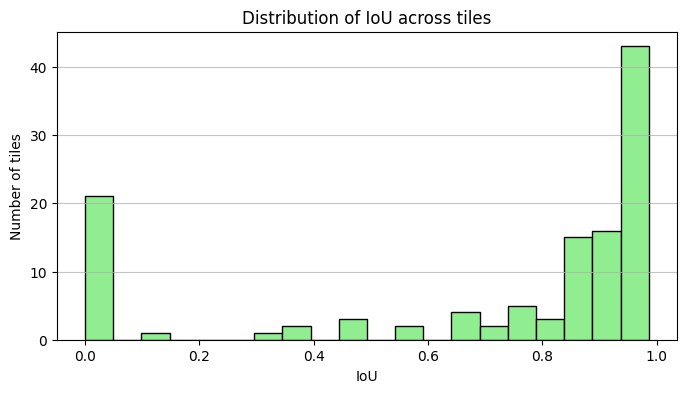

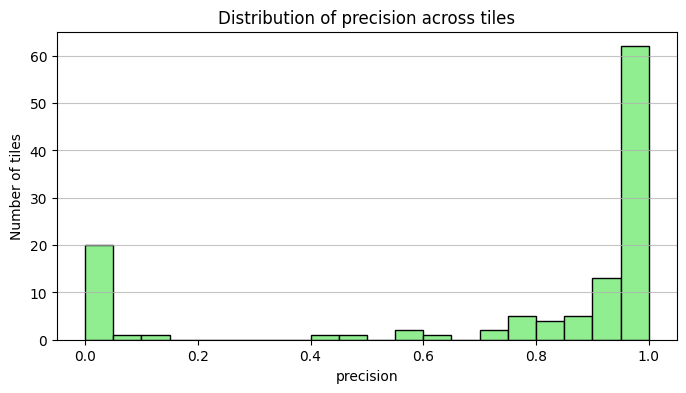

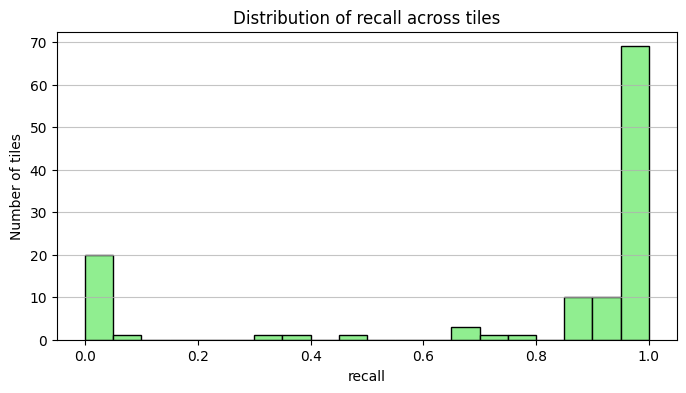

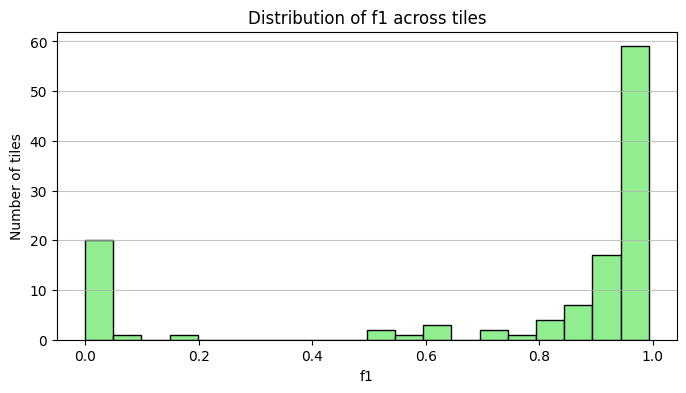

In [85]:
# Plot evaluation metrics distribution
metrics = ["IoU", "precision", "recall", "f1"]
for metric in metrics:
    plt.figure(figsize=(8, 4))
    plt.hist(
        df_eval_results[metric][:-1], bins=20, color="lightgreen", edgecolor="black"
    )
    plt.title(f"Distribution of {metric} across tiles")
    plt.xlabel(metric)
    plt.ylabel("Number of tiles")
    plt.grid(axis="y", alpha=0.75)
    # Save plot
    plt.savefig(f"../runs/modelv4_results/{metric}_distribution.png", dpi=300)
    plt.show()

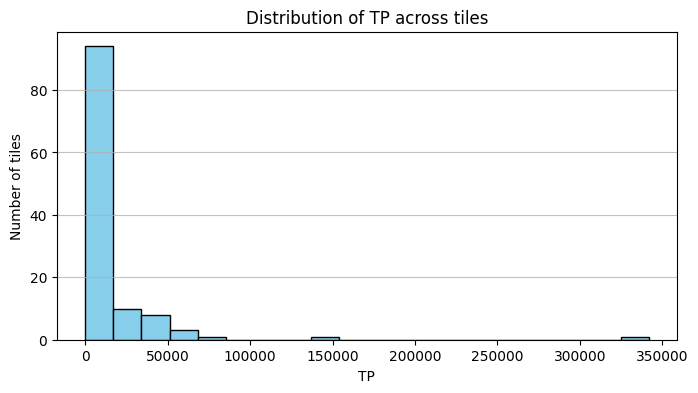

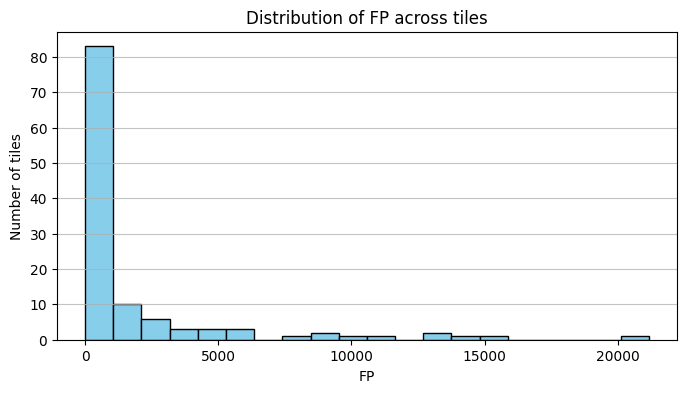

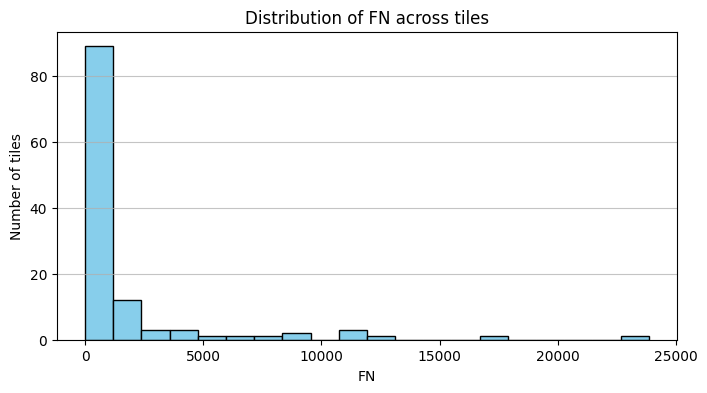

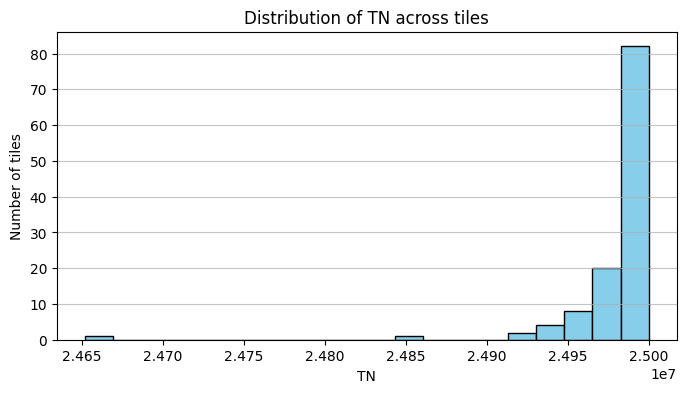

In [86]:
# Plot confusion matrix components distribution
confusion_components = ["TP", "FP", "FN", "TN"]
for component in confusion_components:
    plt.figure(figsize=(8, 4))
    plt.hist(
        df_eval_results[component][:-1], bins=20, color="skyblue", edgecolor="black"
    )
    plt.title(f"Distribution of {component} across tiles")
    plt.xlabel(component)
    plt.ylabel("Number of tiles")
    plt.grid(axis="y", alpha=0.75)
    # Save plot
    plt.savefig(f"../runs/modelv4_results/{component}_distribution.png", dpi=300)
    plt.show()

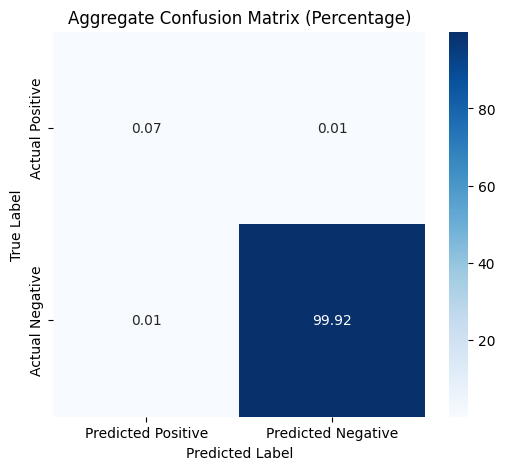

In [87]:
# Plot aggregate confusion matrix
confusion_matrix = np.array(
    [
        [df_eval_results["TP"].iloc[-1], df_eval_results["FP"].iloc[-1]],
        [df_eval_results["FN"].iloc[-1], df_eval_results["TN"].iloc[-1]],
    ]
)
# Convert to percentages
confusion_matrix_percent = confusion_matrix / confusion_matrix.sum() * 100.0

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Predicted Positive", "Predicted Negative"],
    yticklabels=["Actual Positive", "Actual Negative"],
)
plt.title("Aggregate Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# Save plot
plt.savefig("../runs/modelv4_results/aggregate_confusion_matrix.png")
plt.show()

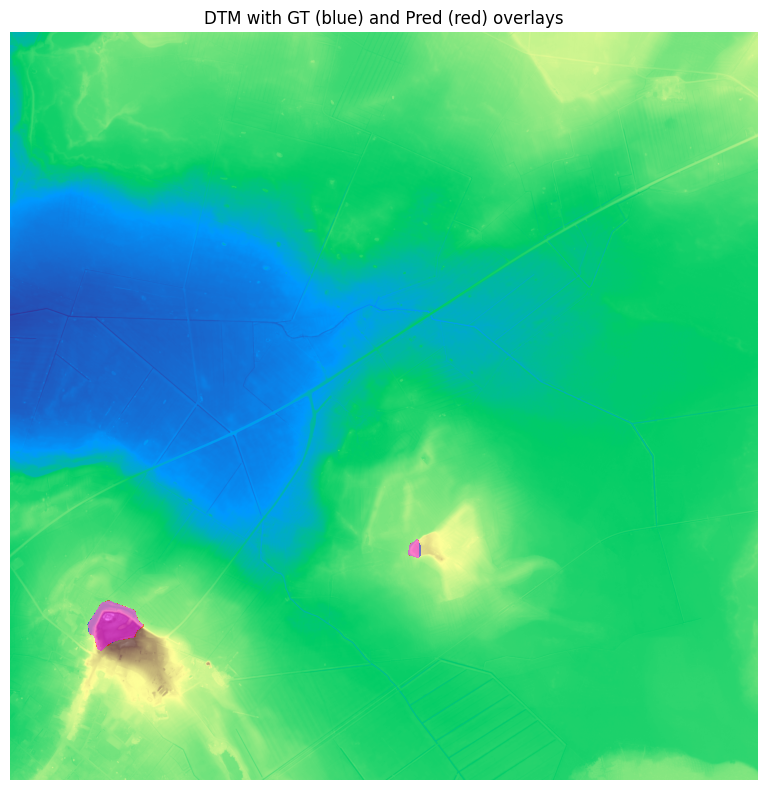

In [88]:
# Choose a single DTM tile to visualize predictions vs ground truth
tile_id = "62093"  # replace with desired tile ID

dtm_path = Path(f"../data/dtm/{tile_id}.tif")
gt_mask_path = Path(f"../data/gt_masks/{tile_id}.png")
pred_mask_path = Path(f"../runs/modelv4_results/eval/{tile_id}.png")
gt_mask = load_mask(gt_mask_path)
pred_mask = load_mask(pred_mask_path)

# print("paths exist:", dtm_path.exists(), gt_mask_path.exists(), pred_mask_path.exists())

# print("shapes:", "dtm unknown here", "gt", gt_mask.shape, "pred", pred_mask.shape)
# print("sums:", "gt_sum", int(gt_mask.sum()), "pred_sum", int(pred_mask.sum()))
# print("gt unique:", np.unique(gt_mask), "pred unique:", np.unique(pred_mask))

# Visualise ground truth mask and predicted mask overlays on DTM
dtm = load_dtm(dtm_path)
fig, ax = plot_dtm_with_two_mask_overlays(
    dtm,
    gt_mask,
    pred_mask,
    alpha=0.5,
    use_hillshade=False,
    # azimuth=315,
    # altitude=45,
    # figsize=(8, 8),
)
# Save plot
fig.savefig(
    f"../runs/modelv4_results/dtm_{tile_id}_gt_pred_overlay_terrain.png", dpi=300
)
plt.show()

### Example of the most positive predicted map tile


In [89]:
from pathlib import Path
from typing import Optional
import csv

import numpy as np
from PIL import Image


def analyze_masks(dir_path: str, out_csv: Optional[str] = None) -> None:
    """
    Scan `dir_path` for images, treat non-zero pixels as positive,
    and print + optionally save per-file counts and proportions.

    Args:
        dir_path: Directory containing binary masks (zeros and ones).
        out_csv: Optional path to write CSV with columns:
                 filename,positive_count,negative_count,positive_fraction
    """
    p = Path(dir_path)
    files = sorted([f for f in p.iterdir() if f.is_file()])
    rows = []
    total_pos = 0
    total_pixels = 0

    for f in files:
        im = Image.open(f).convert("L")
        arr = np.asarray(im)
        pos = int((arr > 0).sum())
        tot = int(arr.size)
        neg = tot - pos
        frac = pos / tot if tot > 0 else 0.0
        rows.append((str(f.name), pos, neg, frac))
        total_pos += pos
        total_pixels += tot
        print(f"{f.name}: pos={pos}, neg={neg}, pos_frac={frac:.6f}")

    print(
        f"Summary: files={len(rows)}, total_pos={total_pos}, total_pixels={total_pixels}, overall_pos_frac={total_pos / total_pixels:.6f}"
    )

    if out_csv:
        with open(out_csv, "w", newline="") as fh:
            writer = csv.writer(fh)
            writer.writerow(
                ["filename", "positive_count", "negative_count", "positive_fraction"]
            )
            for r in rows:
                writer.writerow(r)
        print(f"Wrote CSV: {out_csv}")


binary_mask_dir = "../runs/modelv4_results/eval/"
output_dir = "../runs/modelv4_results/pred_stats.csv"
analyze_masks(binary_mask_dir, output_dir)

44984.png: pos=43972, neg=24956028, pos_frac=0.001759
51782.png: pos=15217, neg=24984783, pos_frac=0.000609
51792.png: pos=36507, neg=24963493, pos_frac=0.001460
51793.png: pos=3163, neg=24996837, pos_frac=0.000127
52613.png: pos=16969, neg=24983031, pos_frac=0.000679
52721.png: pos=17297, neg=24982703, pos_frac=0.000692
52722.png: pos=13237, neg=24986763, pos_frac=0.000529
52741.png: pos=10137, neg=24989863, pos_frac=0.000405
52743.png: pos=11036, neg=24988964, pos_frac=0.000441
52744.png: pos=0, neg=25000000, pos_frac=0.000000
52803.png: pos=6954, neg=24993046, pos_frac=0.000278
52814.png: pos=30919, neg=24969081, pos_frac=0.001237
52843.png: pos=15340, neg=24984660, pos_frac=0.000614
52883.png: pos=0, neg=25000000, pos_frac=0.000000
52951.png: pos=12198, neg=24987802, pos_frac=0.000488
52953.png: pos=4417, neg=24995583, pos_frac=0.000177
52983.png: pos=7323, neg=24992677, pos_frac=0.000293
53691.png: pos=13973, neg=24986027, pos_frac=0.000559
53693.png: pos=21165, neg=24978835, pos_

In [90]:
import pandas as pd

stats_df = pd.read_csv("../runs/modelv4_results/pred_stats.csv")

display(stats_df.sort_values(by="positive_count", ascending=False).head(10))

,filename,positive_count,negative_count,positive_fraction
22,53921.png,346352,24653648,0.013854
33,54311.png,142913,24857087,0.005717
59,62093.png,84830,24915170,0.003393
28,54174.png,68269,24931731,0.002731
112,64951.png,61760,24938240,0.002470
108,64831.png,54102,24945898,0.002164
76,63431.png,54020,24945980,0.002161
75,63422.png,53524,24946476,0.002141
34,54332.png,48725,24951275,0.001949
0,44984.png,43972,24956028,0.001759


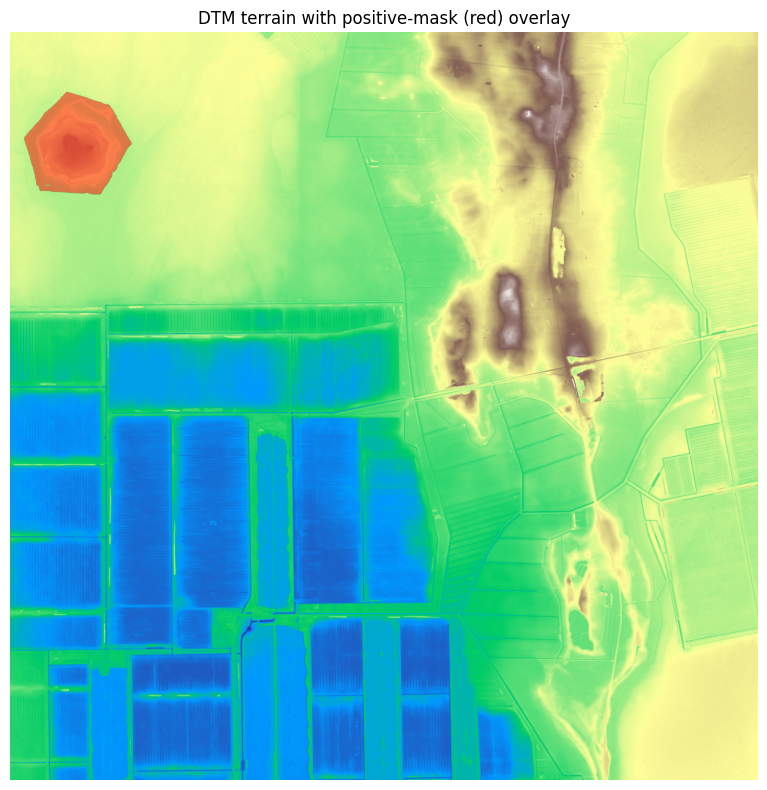

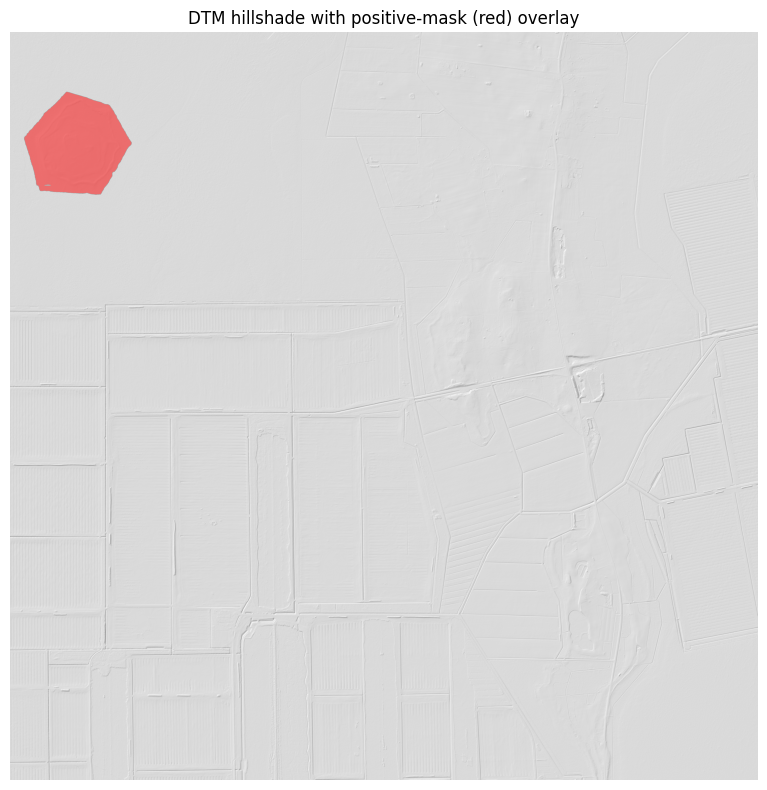

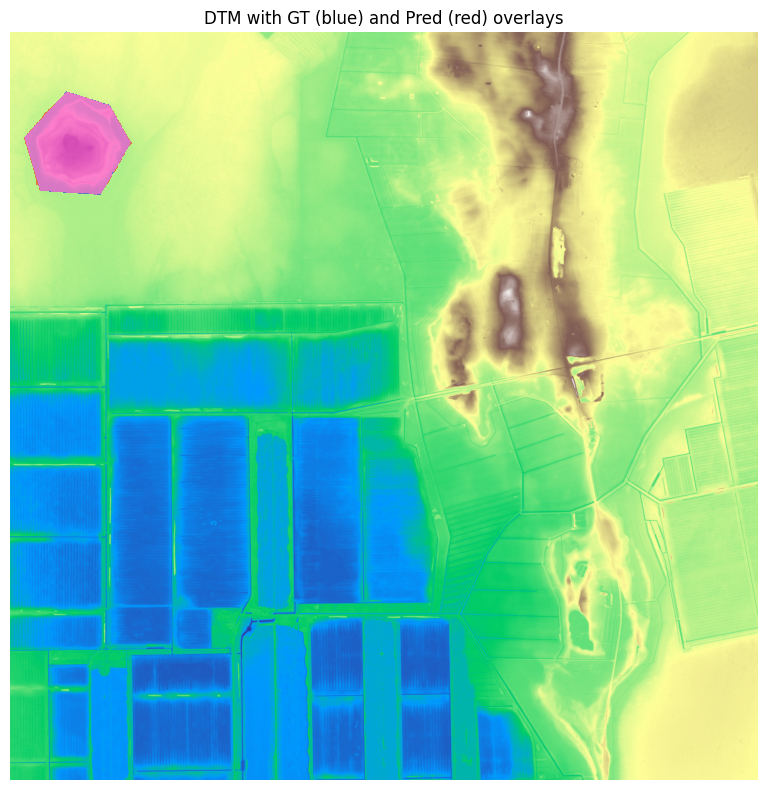

In [91]:
# Choose a single DTM tile to visualize predictions vs ground truth
tile_id = "53921"  # replace with desired tile ID

dtm_path = Path(f"../data/dtm/{tile_id}.tif")
gt_mask_path = Path(f"../data/gt_masks/{tile_id}.png")
pred_mask_path = Path(f"../runs/modelv4_results/eval/{tile_id}.png")
gt_mask = load_mask(gt_mask_path)
pred_mask = load_mask(pred_mask_path)
dtm = load_dtm(dtm_path)

overlay_alpha = 0.5
azimuth = 315
altitude = 45

# print("paths exist:", dtm_path.exists(), gt_mask_path.exists(), pred_mask_path.exists())

# print("shapes:", "dtm unknown here", "gt", gt_mask.shape, "pred", pred_mask.shape)
# print("sums:", "gt_sum", int(gt_mask.sum()), "pred_sum", int(pred_mask.sum()))
# print("gt unique:", np.unique(gt_mask), "pred unique:", np.unique(pred_mask))

# Visualise predicted mask overlay on different terrain backgrounds
plot_terrain_overlay(dtm, pred_mask, overlay_alpha)
plot_hillshade_overlay(dtm, pred_mask, overlay_alpha, azimuth, altitude)

# Visualise ground truth mask and predicted mask overlays on DTM
fig, ax = plot_dtm_with_two_mask_overlays(
    dtm,
    gt_mask,
    pred_mask,
    alpha=0.5,
    use_hillshade=False,
    # azimuth=315,
    # altitude=45,
    # figsize=(8, 8),
)
# Save plot
fig.savefig(
    f"../runs/modelv4_results/dtm_{tile_id}_gt_pred_overlay_terrain.png", dpi=300
)
plt.show()

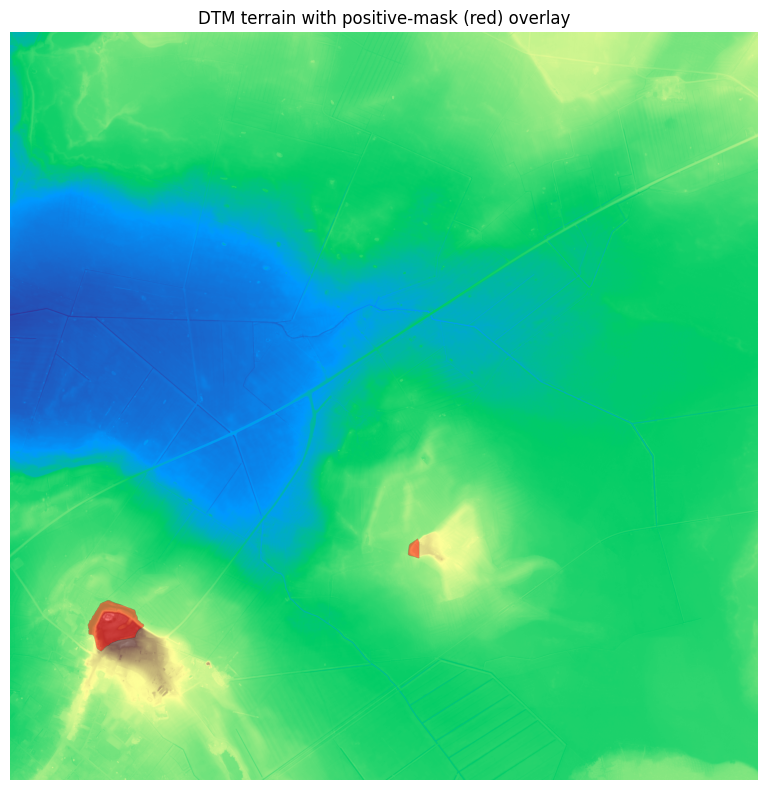

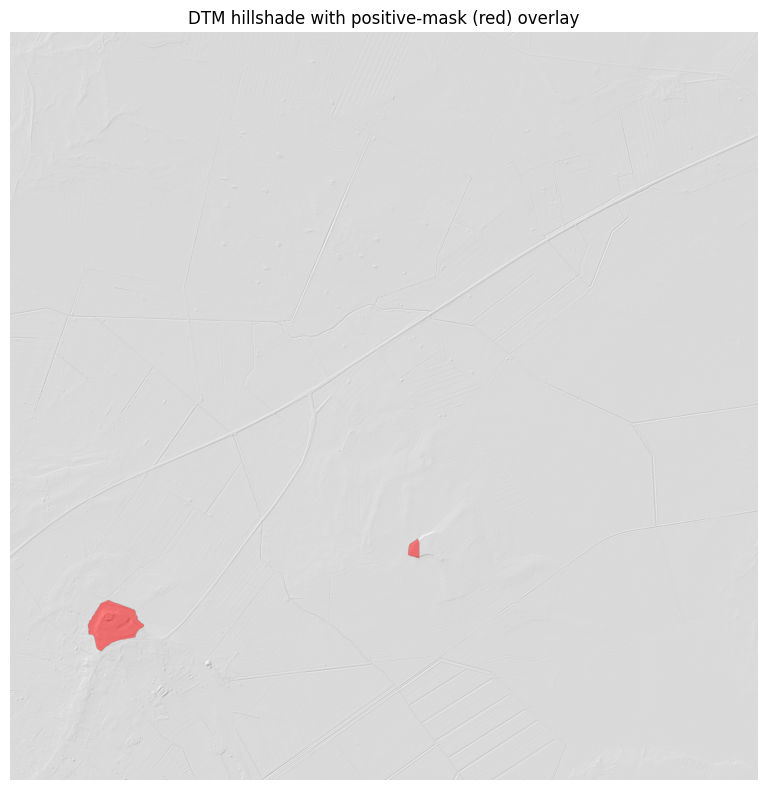

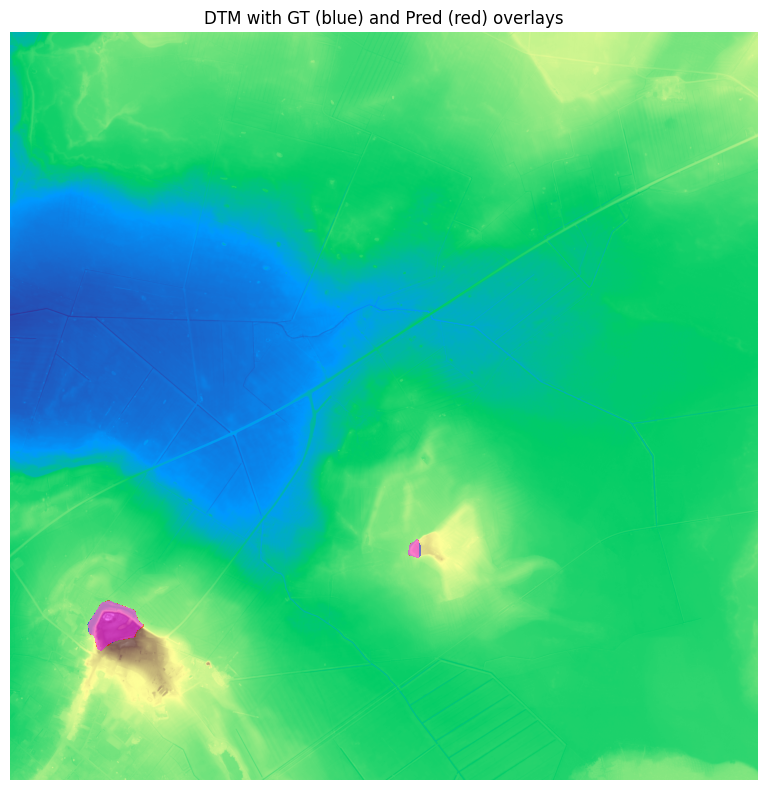

In [92]:
# Choose a single DTM tile to visualize predictions vs ground truth
tile_id = "62093"  # replace with desired tile ID

dtm_path = Path(f"../data/dtm/{tile_id}.tif")
gt_mask_path = Path(f"../data/gt_masks/{tile_id}.png")
pred_mask_path = Path(f"../runs/modelv4_results/eval/{tile_id}.png")
gt_mask = load_mask(gt_mask_path)
pred_mask = load_mask(pred_mask_path)
dtm = load_dtm(dtm_path)

overlay_alpha = 0.5
azimuth = 315
altitude = 45

# print("paths exist:", dtm_path.exists(), gt_mask_path.exists(), pred_mask_path.exists())

# print("shapes:", "dtm unknown here", "gt", gt_mask.shape, "pred", pred_mask.shape)
# print("sums:", "gt_sum", int(gt_mask.sum()), "pred_sum", int(pred_mask.sum()))
# print("gt unique:", np.unique(gt_mask), "pred unique:", np.unique(pred_mask))

# Visualise predicted mask overlay on different terrain backgrounds
plot_terrain_overlay(dtm, pred_mask, overlay_alpha)
plot_hillshade_overlay(dtm, pred_mask, overlay_alpha, azimuth, altitude)

# Visualise ground truth mask and predicted mask overlays on DTM
fig, ax = plot_dtm_with_two_mask_overlays(
    dtm,
    gt_mask,
    pred_mask,
    alpha=0.5,
    use_hillshade=False,
    # azimuth=315,
    # altitude=45,
    # figsize=(8, 8),
)
# Save plot
fig.savefig(
    f"../runs/modelv4_results/dtm_{tile_id}_gt_pred_overlay_terrain.png", dpi=300
)
plt.show()